# SSO Signup Optimization — First Fix (Secondary Metric): Bayesian Re-analysis

**Experiment:** SSO Signup Optimization (A/B/C) · **Owner:** Sergio Oyola · **Metric:** Visitor First Fix Request Flag Up to 7 Days (boolean, tracked as a **secondary** metric; VSR was primary) · **Randomization unit:** `visitor_id` · **Source:** Reporter, inference as of July 24, 2026

## Why Bayesian?

The frequentist Reporter results are **not significant** at α=0.05 for either variant:

| Cell | n | Rate | Abs. effect vs. Control | Rel. effect | p-value |
|---|---|---|---|---|---|
| Variant A — Balanced Email-First | 43,623 | 10.41% | +0.0017 (−0.0024, +0.0057) | +1.63% (−2.31%, +5.56%) | 0.42 |
| Variant B — SSO-First | 43,966 | 10.63% | +0.0039 (−0.00019, +0.0079) | +3.77% (−0.18%, +7.72%) | **0.062** |

Variant B sits just above the conventional 0.05 threshold, and its CI barely crosses zero — a "not significant" verdict hides how close this is. A binary significant/not-significant read throws away that information. A **Bayesian re-analysis** answers the following question directly: **given the data, what's the probability Variant B actually beats Control, and by how much?**

## 1. Setup: inputs and the Beta-Binomial model

Each arm's First Fix rate is modeled as a Binomial(`n`, `p`) with a **Beta prior** on `p` — the standard conjugate model for a boolean conversion metric. We use a weakly-informative **Beta(1, 1)** (uniform) prior: no arm is assumed to differ from any other beforehand, so the posterior is driven entirely by the observed data. The posterior is then also Beta:

`p | data ~ Beta(alpha_prior + successes, beta_prior + failures)`

closed-form, no Markov Chain Monte Carlo (MCMC) required.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
np.random.seed(42)

# Observed results — Reporter, as of 2026-07-27 (Visitor First Fix Request Flag Up to 7 Days)
CELL_N    = {'Control': 43_864, 'Variant A': 43_623, 'Variant B': 43_966}
CELL_RATE = {'Control': 0.1024, 'Variant A': 0.1041, 'Variant B': 0.1063}

print(f"Observed results: \n ABS: {CELL_N} \n PER: {CELL_RATE}")

Observed results: 
 ABS: {'Control': 43864, 'Variant A': 43623, 'Variant B': 43966} 
 PER: {'Control': 0.1024, 'Variant A': 0.1041, 'Variant B': 0.1063}


## 2. Successes and failures

Raw counts the Bayesian model needs to run are obtained from the metrics.

* **Successes:** how many visitors in the arm did request a First Fix within 7 days. Back-solved since Reporter exposes the rate rounded to 4 decimals.
* **Failures:** everyone else in the arm who didn't request a First Fix within 7 days -> (n - successes).

In [2]:
# Back-solve approximate success/failure counts from Reporter's rounded rates
successes = {k: int(round(CELL_RATE[k] * CELL_N[k])) for k in CELL_N}
failures  = {k: CELL_N[k] - successes[k] for k in CELL_N}

input_df = pd.DataFrame({
    'n': CELL_N,
    'observed_rate': CELL_RATE,
    'successes (back-solved)': successes,
    'failures': failures,
}).loc[['Control', 'Variant A', 'Variant B']]
input_df

,n,observed_rate,successes (back-solved),failures
Control,43864,0.1024,4492,39372
Variant A,43623,0.1041,4541,39082
Variant B,43966,0.1063,4674,39292


## 3. Posterior distributions per arm

Combine each arm's Beta(1,1) prior with its successes/failures from the previous step to get its posterior Beta distribution, then draw Monte Carlo samples we'll reuse in every comparison below.

* **Posterior parameters:** `Beta(1 + successes, 1 + failures)` per arm.
* **Samples:** 500,000 draws per arm, reused for all pairwise comparisons later in the notebook.
* **Summary table:** posterior mean and 95% credible interval per arm.

In [3]:
ALPHA_PRIOR, BETA_PRIOR = 1.0, 1.0  # Beta(1,1): uniform / weakly-informative

posterior_params = {k: (ALPHA_PRIOR + successes[k], BETA_PRIOR + failures[k]) for k in CELL_N}

N_SAMPLES = 500_000
post_rows, samples = [], {}
for k, (a, b) in posterior_params.items():
    dist = stats.beta(a, b)
    lo, hi = dist.ppf(0.025), dist.ppf(0.975)
    post_rows.append({'alpha_post': a, 'beta_post': b, 'posterior_mean': dist.mean(),
                       'cred_lo_2.5%': lo, 'cred_hi_97.5%': hi})
    samples[k] = dist.rvs(N_SAMPLES, random_state=np.random.RandomState(hash(k) % 2**31))

post_df = pd.DataFrame(post_rows, index=list(posterior_params.keys()))
post_df.index.name = 'arm'
post_df

,alpha_post,beta_post,posterior_mean,cred_lo_2.5%,cred_hi_97.5%
arm,,,,,
Control,4493.0,39373.0,0.102426,0.099605,0.105280
Variant A,4542.0,39083.0,0.104115,0.101266,0.106998
Variant B,4675.0,39293.0,0.106327,0.103463,0.109226


- **alpha_post / beta_post**: each arm's updated Beta distribution: Beta(1 + successes, 1 + failures). This is the posterior — a full probability distribution over "what is this arm's
true First Fix rate," not just a point estimate.
- **posterior_mean**: sits almost exactly on the raw observed rate (10.24% -> 0.102426, 10.41% -> 0.104115, 10.63% -> 0.106327). That's expected: with a weak Beta(1,1) prior and ~44k observations per arm, the data completely dominates — the prior barely nudges the estimate.
- **cred_lo_2.5% / cred_hi_97.5%**: the 95% credible interval, meaning: given the data and the prior, there's a 95% probability the arm's true rate lies in this range. That's a direct
probability statement about the parameter, philosophically different from a frequentist CI's "coverage" definition — though numerically they land in nearly the same place here. With a uniform prior and this sample size, the 95% credible intervals above (e.g. Variant B: 10.35%–10.92%) closely match the frequentist confidence intervals from Reporter — this is expected (Bayesian and frequentist intervals converge at large n) and confirms the model isn't distorting the data, just reframing the question.

## 4. Visualizing the posteriors

A picture of the three posterior distributions from the table above — how much they overlap is a quick visual read on how distinguishable the arms are, before we quantify that overlap with actual probabilities in the next step.

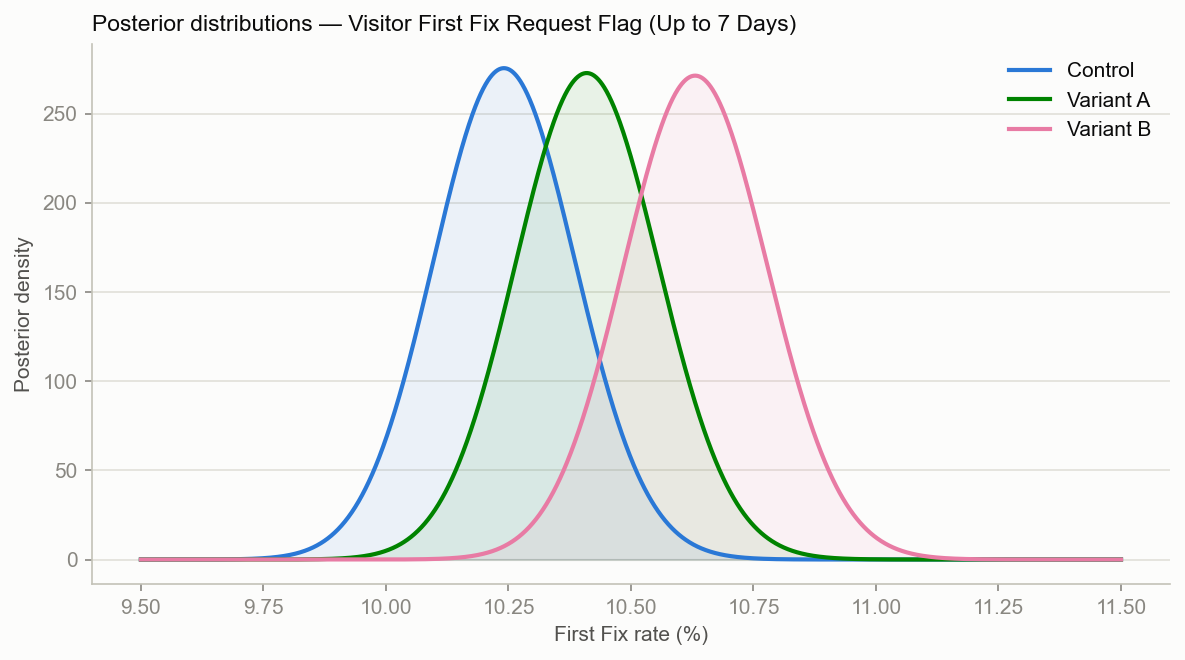

In [4]:
BLUE, GREEN, MAGENTA = '#2a78d6', '#008300', '#e87ba4'   # dataviz categorical slots 1-3 (Control / A / B)
SURFACE, PRIMARY_INK, SECONDARY_INK = '#fcfcfb', '#0b0b0b', '#52514e'
MUTED, GRID, BASELINE_C = '#898781', '#e1e0d9', '#c3c2b7'
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.edgecolor': BASELINE_C, 'axes.labelcolor': SECONDARY_INK, 'text.color': PRIMARY_INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
})
colors = {'Control': BLUE, 'Variant A': GREEN, 'Variant B': MAGENTA}

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
x = np.linspace(0.095, 0.115, 2000)
for k, (a, b) in posterior_params.items():
    y = stats.beta(a, b).pdf(x)
    ax.plot(x * 100, y, color=colors[k], lw=2, label=k)
    ax.fill_between(x * 100, y, color=colors[k], alpha=0.08)
ax.set_xlabel('First Fix rate (%)')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior distributions — Visitor First Fix Request Flag (Up to 7 Days)', fontsize=11, loc='left')
ax.grid(axis='y', color=GRID, lw=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()
plt.show()

## 5. Monte Carlo comparison: P(variant beats Control), lift, expected loss

A Beta-minus-Beta difference has no simple closed form, so we simulate: draw 500,000 samples from each arm's posterior and compute, pairwise against Control:
- **P(variant > Control)** — the probability the variant is actually better (the direct answer to "is this close to a positive effect?")
- **Lift** (absolute and relative), with a 95% credible interval
- **Expected loss** — the average shortfall if we shipped this variant and it turned out to actually be worse than Control (a risk-sizing number, not a significance test)

In [5]:
results = []
for variant in ['Variant A', 'Variant B']:
    diff = samples[variant] - samples['Control']
    rel = diff / samples['Control']
    p_gt = (diff > 0).mean()
    abs_lo, abs_med, abs_hi = np.percentile(diff, [2.5, 50, 97.5])
    rel_lo, rel_med, rel_hi = np.percentile(rel, [2.5, 50, 97.5])
    expected_loss = np.mean(np.maximum(samples['Control'] - samples[variant], 0))
    results.append({
        'variant': variant, 'P(variant > Control)': p_gt,
        'abs_lift_median': abs_med, 'abs_lift_2.5%': abs_lo, 'abs_lift_97.5%': abs_hi,
        'rel_lift_median': rel_med, 'rel_lift_2.5%': rel_lo, 'rel_lift_97.5%': rel_hi,
        'expected_loss_abs': expected_loss,
    })
res_df = pd.DataFrame(results).set_index('variant')
res_df

,P(variant > Control),abs_lift_median,abs_lift_2.5%,abs_lift_97.5%,rel_lift_median,rel_lift_2.5%,rel_lift_97.5%,expected_loss_abs
variant,,,,,,,,
Variant A,0.794566,0.001691,-0.002340,0.005715,0.016508,-0.022423,0.056901,0.000238
Variant B,0.970684,0.003897,-0.000143,0.007934,0.038056,-0.001372,0.079019,0.000023


### Visualizing the lift distributions

The table above gives the numbers; this plot shows the full lift distribution for each variant against Control, with the probability mass below zero shaded so the remaining downside risk is obvious at a glance.

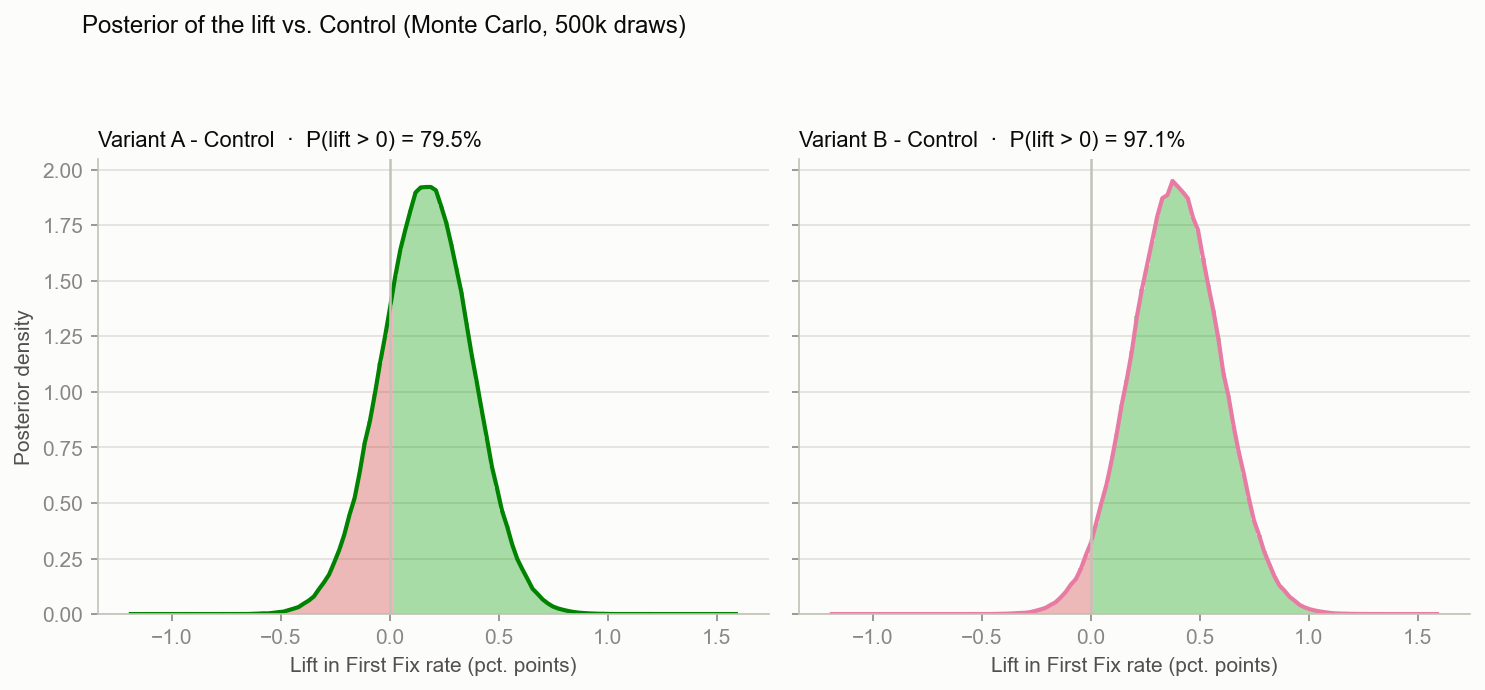

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), dpi=150, sharex=True, sharey=True)
fig.suptitle('Posterior of the lift vs. Control (Monte Carlo, 500k draws)', fontsize=11.5, x=0.06, ha='left', y=0.99)
GOOD, CRITICAL = '#0ca30c', '#d03b3b'
for ax, variant, color in zip(axes, ['Variant A', 'Variant B'], [GREEN, MAGENTA]):
    diff = (samples[variant] - samples['Control']) * 100
    p_gt = (diff > 0).mean()
    counts, bins = np.histogram(diff, bins=120, range=(-1.2, 1.6))
    counts = counts / counts.sum() / np.diff(bins)
    for i in range(len(counts)):
        c = GOOD if bins[i] >= 0 else CRITICAL
        ax.bar(bins[i], counts[i], width=np.diff(bins)[i], align='edge', color=c, alpha=0.35, linewidth=0)
    ax.plot((bins[:-1] + bins[1:]) / 2, counts, color=color, lw=2)
    ax.axvline(0, color=BASELINE_C, lw=1.2, zorder=3)
    ax.set_title(f"{variant} - Control  ·  P(lift > 0) = {p_gt:.1%}", fontsize=10.5, loc='left')
    ax.set_xlabel('Lift in First Fix rate (pct. points)')
    ax.grid(axis='y', color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('Posterior density')
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 6. Which arm is most likely the true winner?

Every comparison so far has been pairwise against Control. This last check asks the three-way question directly: for each simulated draw, which arm has the highest rate — and specifically, how often does Variant B beat Variant A head-to-head?

In [ ]:
# Probability each arm is the single best of the three (accounts for A and B both beating Control at once)
stacked = np.vstack([samples['Control'], samples['Variant A'], samples['Variant B']])
best_idx = np.argmax(stacked, axis=0)
best_df = pd.Series(
    {k: (best_idx == i).mean() for i, k in enumerate(['Control', 'Variant A', 'Variant B'])},
    name='P(arm is best of 3)',
).to_frame() # Compares the three arms simultaneously, not just A vs. B

p_b_gt_a = (samples['Variant B'] > samples['Variant A']).mean() # Ignores Control, just compares A vs. B
print(f"P(Variant B > Variant A) = {p_b_gt_a:.1%}")
best_df

P(Variant B > Variant A) = 85.7%


,P(arm is best of 3)
Control,0.018976
Variant A,0.138108
Variant B,0.842916


## Bottom line

- **Variant B likely has a modest positive effect on First Fix**, altough it misses the conventional 0.05 significance threshold. It's the most probable overall winner**: **P(B is the best of the three arms) ~ 84.4%**, and **P(B > A) ~ 85.7%**.
- **Variant A is directionally positive but much less conclusive**: P(A > Control) ~ 79.4%, well short of the confidence we'd want before treating it as a real effect — consistent with its frequentist p=0.42.
- **Expected loss for this metric if rolling out B is small** (~0.0002 absolute, i.e. ~2 fewer First Fixes per 10,000 visitors in the downside case) — the downside risk of choosing B over Control is low relative to the upside.
- This is a **probability statement, not a "roll out" recommendation** — it doesn't by itself account for the pre-registered VSR primary-metric result, business cost of rolling out, or multiple-comparison concerns for VSR + secondary metrics.